# PCB Defect Detection : New Frameworks

1. **SSL** - Self-supervised learning for feature extraction without labels
2. **FSL** - Few-shot learning for classification with minimal labeled data  
3. **RL** - Reinforcement learning for intelligent sample selection


In [ ]:
# Standard library imports
import os
import json
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Data manipulation and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

# Image processing
import cv2

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

# TensorFlow and Keras
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import MobileNetV2

# Constants - Optimized for Better Accuracy
TARGET_SIZE = (224, 224)
BATCH_SIZE = 32
SSL_EPOCHS = 50
FSL_SHOTS = 5
RANDOM_STATE = 42

# Edge-friendly configurations
USE_MOBILENET_ENCODER = True
MODEL_COMPRESSION = True
QUANTIZATION_READY = True

print("All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

All libraries imported successfully!
TensorFlow version: 2.18.0
GPU available: []


## 1. Data Loading and Preparation

First, we load the dataset from the JSON annotations and prepare it for the different learning stages. We will split the data into:
- An **unlabeled pool** for Self-Supervised Learning.
- A **labeled pool** which we will further split into a small support set for Few-Shot Learning and a larger test set for evaluation.

In [2]:
# Define the directory containing the labeled dataset
dataset_dir = r'C:\Users\david\Desktop\project\dataset\Labeled'
print(f"Loading data from: {dataset_dir}")

# Initialize list to store image-label pairs
data = []
for filename in os.listdir(dataset_dir):
    if filename.lower().endswith('.jpg'):
        image_path = os.path.join(dataset_dir, filename)
        json_path = image_path.replace('.jpg', '.json')
        
        label = None
        if os.path.exists(json_path):
            try:
                with open(json_path, 'r') as f:
                    content = json.load(f)
                    shapes = content.get('shapes', [])
                    if shapes:
                        label = shapes[0].get('label')
            except Exception as e:
                print(f"Error reading {json_path}: {e}")
        
        if label and label != 'no_good': # Filter out 'no_good' and unlabeled
            data.append({'filename': image_path, 'label': label})

# Create DataFrame
df = pd.DataFrame(data)
print(f"Total labeled samples (excluding 'no_good'): {len(df)}")
print(f"Unique labels: {df['label'].unique()}")

# Encode labels to integers
label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['label'])
class_indices = {label: idx for idx, label in enumerate(label_encoder.classes_)}
num_classes = len(class_indices)

# Split data: 80% for SSL (treated as unlabeled) and FSL/RL, 20% for final testing
train_df, test_df = train_test_split(df, test_size=0.2, random_state=RANDOM_STATE, stratify=df['label'])

# The train_df will be our pool for SSL, FSL support, and RL active learning
unlabeled_pool_df = train_df.copy()
fsl_pool_df = train_df.copy()

print(f"\nData Split:")
print(f"- Unlabeled pool for SSL: {len(unlabeled_pool_df)} samples")
print(f"- Pool for FSL/RL: {len(fsl_pool_df)} samples")
print(f"- Final test set: {len(test_df)} samples")

Loading data from: C:\Users\david\Desktop\project\dataset\Labeled
Total labeled samples (excluding 'no_good'): 312
Unique labels: ['good' 'exc_solder' 'poor_solder' 'spike']

Data Split:
- Unlabeled pool for SSL: 249 samples
- Pool for FSL/RL: 249 samples
- Final test set: 63 samples


## 2. Stage 1: Self-Supervised Learning (SSL) with SimCLR

We'll pre-train a ResNet50 encoder using the SimCLR contrastive learning method. The goal is to learn meaningful representations of PCB images without using any labels.

The process involves creating two augmented "views" of each image and training the model to identify these views as a positive pair, while pushing them away from all other images.

In [ ]:
# --- Augmentation Pipeline for Contrastive Learning ---
def get_ssl_augmenter(height, width, temperature):
    return tf.keras.Sequential([
        layers.Resizing(height, width),
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.15),
        layers.RandomZoom(height_factor=0.3, width_factor=0.3),
        layers.RandomContrast(0.3),
        layers.RandomBrightness(0.2),
        layers.RandomTranslation(0.1, 0.1),
    ])

# --- Data Pipeline for SSL ---
def load_and_augment_image(file_path):
    image = tf.io.read_file(file_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.convert_image_dtype(image, tf.float32)
    return image

ssl_augmenter = get_ssl_augmenter(*TARGET_SIZE, 0.1)

def create_ssl_dataset(image_paths):
    dataset = tf.data.Dataset.from_tensor_slices(image_paths)
    dataset = dataset.shuffle(1024, seed=RANDOM_STATE)
    dataset = dataset.map(load_and_augment_image, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.map(lambda x: (ssl_augmenter(x), ssl_augmenter(x)), num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

ssl_dataset = create_ssl_dataset(unlabeled_pool_df['filename'].values)

# --- SimCLR Model and Loss - Edge Optimized ---
def get_ssl_encoder(input_shape):
    base_encoder = MobileNetV2(include_top=False, weights='imagenet', 
                               input_shape=input_shape, alpha=1.0)
    
    # Fine-tune more layers for better learning
    for layer in base_encoder.layers[:-20]:
        layer.trainable = False
    
    return models.Sequential([
        base_encoder,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),  # Increased capacity
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),  # Additional layer
        layers.Dropout(0.2),
    ], name="ssl_encoder")

def get_projection_head(input_shape):
    # Lightweight projection head for edge deployment
    return models.Sequential([
        layers.Input(shape=input_shape),
        layers.Dense(64, activation="relu"), 
        layers.Dropout(0.2),
        layers.Dense(32),
    ], name="projection_head")

class SimCLR(models.Model):
    def __init__(self, encoder, projection_head, temperature=0.1):
        super().__init__()
        self.encoder = encoder
        self.projection_head = projection_head
        self.temperature = temperature
        self.loss_tracker = tf.keras.metrics.Mean(name="loss")

    def compile(self, optimizer, **kwargs):
        super().compile(**kwargs)
        self.optimizer = optimizer

    def train_step(self, data):
        images_1, images_2 = data
        
        with tf.GradientTape() as tape:
            # Get representations
            h1 = self.encoder(images_1)
            h2 = self.encoder(images_2)
            
            # Get projections
            z1 = self.projection_head(h1)
            z2 = self.projection_head(h2)
            
            # Normalize projections
            z1 = tf.math.l2_normalize(z1, axis=1)
            z2 = tf.math.l2_normalize(z2, axis=1)
            
            # Calculate loss
            similarity_matrix = tf.matmul(z1, z2, transpose_b=True)
            labels = tf.range(tf.shape(z1)[0])
            loss = tf.keras.losses.sparse_categorical_crossentropy(
                labels, similarity_matrix / self.temperature, from_logits=True
            )
        
        # Compute gradients and update weights
        gradients = tape.gradient(loss, self.encoder.trainable_variables + self.projection_head.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.encoder.trainable_variables + self.projection_head.trainable_variables))
        
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

# --- Train SSL Model ---
print("Starting Self-Supervised Learning...")
ssl_encoder = get_ssl_encoder((*TARGET_SIZE, 3))

# Build the encoder to define its output shape before using it
ssl_encoder.build((None, *TARGET_SIZE, 3))

projection_head = get_projection_head(ssl_encoder.output_shape[1:])
simclr_model = SimCLR(ssl_encoder, projection_head)

simclr_model.compile(optimizer=optimizers.Adam(0.001))
history = simclr_model.fit(ssl_dataset, epochs=SSL_EPOCHS)

print("\nSSL training complete.")
model_save_path = "../model/ssl_encoder.weights.h5"
ssl_encoder.save_weights(model_save_path)
print(f"SSL encoder weights saved to {model_save_path}")

Starting Self-Supervised Learning...
Epoch 1/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 47s 3s/step - loss: 4.1396
Epoch 2/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - loss: 3.7895
Epoch 3/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step - loss: 4.1483
Epoch 4/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - loss: 4.1483
Epoch 5/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - loss: 4.1483

SSL training complete.
SSL encoder weights saved to ../model/ssl_encoder.weights.h5


## 3. Stage 2: Few-Shot Learning with Prototypical Networks

With our powerful SSL feature extractor, we now build a Prototypical Network. This model can classify images based on their distance to class "prototypes" in the feature space. We will create these prototypes using only a small "support set" of K-shot labeled images.

In [ ]:
# --- Load the SSL Encoder ---
fsl_encoder = get_ssl_encoder((*TARGET_SIZE, 3))
fsl_encoder.load_weights("../model/ssl_encoder.weights.h5")
fsl_encoder.trainable = False # Freeze the encoder
print("SSL encoder loaded and frozen for FSL.")

# --- FSL Data Preparation ---
def create_fsl_support_set(df, n_shot, n_classes):
    # Use group_keys=False to preserve original indices and handle small classes.
    support_df = df.groupby('label_encoded', group_keys=False).apply(
        lambda x: x.sample(min(n_shot, len(x)), random_state=RANDOM_STATE)
    )
    
    # The remaining data becomes the unlabeled pool for active learning.
    # Dropping now works because support_df has the correct original indices.
    unlabeled_rl_pool_df = df.drop(support_df.index)
    
    return support_df, unlabeled_rl_pool_df

# Create the initial K-shot support set
support_df, unlabeled_rl_pool_df = create_fsl_support_set(fsl_pool_df, FSL_SHOTS, num_classes)
print(f"Created {FSL_SHOTS}-shot support set with {len(support_df)} samples.")
print(f"Remaining unlabeled pool for active learning: {len(unlabeled_rl_pool_df)} samples.")

# --- Prototypical Network Logic ---
def compute_prototypes(support_df, encoder):
    """Edge-optimized prototype computation with data augmentation"""
    prototypes = {}
    
    # Load images with minimal but effective augmentation for edge deployment
    support_images = []
    for img_path in support_df['filename'].values:
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, TARGET_SIZE)
        support_images.append(img)
    
    support_images = np.array(support_images).astype('float32') / 255.0
    
    # Apply minimal augmentation for edge efficiency but better prototypes
    augmented_images = []
    augmented_labels = []
    
    for i, img in enumerate(support_images):
        label = support_df['label_encoded'].iloc[i]
        
        # Original image
        augmented_images.append(img)
        augmented_labels.append(label)
        
        # Only horizontal flip - most effective and fastest augmentation
        flipped = np.fliplr(img)
        augmented_images.append(flipped)
        augmented_labels.append(label)
    
    augmented_images = np.array(augmented_images)
    embeddings = encoder.predict(augmented_images, batch_size=BATCH_SIZE)
    
    # Calculate weighted prototypes (giving more weight to original images)
    for class_id in support_df['label_encoded'].unique():
        class_embeddings = []
        weights = []
        
        for i, label in enumerate(augmented_labels):
            if label == class_id:
                class_embeddings.append(embeddings[i])
                # Give original images more weight than augmented ones
                weights.append(1.0 if i % 2 == 0 else 0.7)
        
        class_embeddings = np.array(class_embeddings)
        weights = np.array(weights)
        
        # Weighted average
        weighted_prototype = np.average(class_embeddings, axis=0, weights=weights)
        prototypes[class_id] = weighted_prototype
        
    return prototypes

def classify_with_prototypes(image_paths, encoder, prototypes):
    """Edge-optimized classification with ensemble voting"""
    # Load images efficiently
    images = []
    for img_path in image_paths:
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, TARGET_SIZE)
        images.append(img)
    
    images = np.array(images).astype('float32') / 255.0
    
    # Get predictions using multiple methods for better accuracy
    predictions_cosine = []
    predictions_euclidean = []
    
    embeddings = encoder.predict(images, batch_size=BATCH_SIZE)
    
    for emb in embeddings:
        # Method 1: Cosine similarity
        cosine_similarities = {}
        emb_norm = emb / (np.linalg.norm(emb) + 1e-8)
        
        for cid, proto in prototypes.items():
            proto_norm = proto / (np.linalg.norm(proto) + 1e-8)
            similarity = np.dot(emb_norm, proto_norm)
            cosine_similarities[cid] = similarity
        
        pred_cosine = max(cosine_similarities, key=cosine_similarities.get)
        predictions_cosine.append(pred_cosine)
        
        # Method 2: Euclidean distance (faster for edge deployment)
        euclidean_distances = {}
        for cid, proto in prototypes.items():
            distance = np.linalg.norm(emb - proto)
            euclidean_distances[cid] = distance
        
        pred_euclidean = min(euclidean_distances, key=euclidean_distances.get)
        predictions_euclidean.append(pred_euclidean)
    
    # Ensemble voting - use both methods and pick majority
    final_predictions = []
    for i in range(len(predictions_cosine)):
        if predictions_cosine[i] == predictions_euclidean[i]:
            # Both methods agree
            final_predictions.append(predictions_cosine[i])
        else:
            # Use cosine similarity as tie-breaker (usually more reliable)
            final_predictions.append(predictions_cosine[i])
    
    return np.array(final_predictions)

# --- Initial FSL Model Evaluation ---
print("\nEvaluating initial FSL model...")
initial_prototypes = compute_prototypes(support_df, fsl_encoder)
initial_predictions = classify_with_prototypes(test_df['filename'].values, fsl_encoder, initial_prototypes)
initial_accuracy = accuracy_score(test_df['label_encoded'].values, initial_predictions)

print(f"Initial FSL Accuracy ({FSL_SHOTS}-shot): {initial_accuracy:.4f}")

SSL encoder loaded and frozen for FSL.
Created 5-shot support set with 20 samples.
Remaining unlabeled pool for active learning: 229 samples.

Evaluating initial FSL model...
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Initial FSL Accuracy (5-shot): 0.3968


## 4. Stage 3: RL-Inspired Active Learning

Now, we simulate an RL agent to perform active learning. Instead of a complex RL agent, we use a practical proxy: **uncertainty sampling**. The "agent" will select samples from the unlabeled pool that the current FSL model is most uncertain about. This is a highly effective strategy that mimics an RL agent's goal of picking the most informative data to label.

The reward is implicit: by picking uncertain samples, we aim to maximize the model's accuracy improvement with each new label.

In [ ]:
def get_model_uncertainty(image_paths, encoder, prototypes):
    """Calculate uncertainty using entropy-based measure with cosine similarity."""
    images = []
    for img_path in image_paths:
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, TARGET_SIZE)
        images.append(img)
    
    images = np.array(images).astype('float32') / 255.0
    embeddings = encoder.predict(images, batch_size=BATCH_SIZE)
    
    uncertainties = []
    for emb in embeddings:
        similarities = []
        emb_norm = emb / np.linalg.norm(emb)
        
        for proto in prototypes.values():
            proto_norm = proto / np.linalg.norm(proto)
            similarity = np.dot(emb_norm, proto_norm)
            similarities.append(similarity)
        
        # Convert similarities to probabilities using softmax
        similarities = np.array(similarities)
        # Apply temperature scaling to make probabilities more discriminative
        temperature = 0.5
        exp_sim = np.exp(similarities / temperature)
        probabilities = exp_sim / np.sum(exp_sim)
        
        # Calculate entropy (higher entropy = more uncertain)
        entropy = -np.sum(probabilities * np.log(probabilities + 1e-8))
        uncertainties.append(entropy)
        
    return np.array(uncertainties)

# --- Active Learning Loop with Diversity Sampling ---
N_ACTIVE_LEARNING_STEPS = 8  # Slightly reduced due to larger FSL_SHOTS
SAMPLES_PER_STEP = 8  # Increased for faster learning

print(f"\nStarting Active Learning for {N_ACTIVE_LEARNING_STEPS} steps...")

active_learning_history = [{'step': 0, 'accuracy': initial_accuracy, 'support_set_size': len(support_df)}]
current_prototypes = initial_prototypes
current_support_df = support_df.copy()

for step in tqdm(range(1, N_ACTIVE_LEARNING_STEPS + 1)):
    # 1. Agent selects most uncertain samples with diversity
    uncertainties = get_model_uncertainty(unlabeled_rl_pool_df['filename'].values, fsl_encoder, current_prototypes)
    
    # Select top uncertain samples (2x what we need)
    top_uncertain_indices = np.argsort(uncertainties)[-SAMPLES_PER_STEP * 2:]
    
    # From top uncertain, select diverse samples (simple diversity by spreading selection)
    selected_indices = []
    for i in range(SAMPLES_PER_STEP):
        idx = top_uncertain_indices[i * 2]  # Take every other sample for diversity
        if idx < len(unlabeled_rl_pool_df):
            selected_indices.append(idx)
    
    # Fallback if we don't have enough samples
    while len(selected_indices) < min(SAMPLES_PER_STEP, len(unlabeled_rl_pool_df)):
        remaining_indices = set(range(len(unlabeled_rl_pool_df))) - set(selected_indices)
        if remaining_indices:
            selected_indices.append(list(remaining_indices)[0])
        else:
            break
    
    # 2. "Label" these samples and add to support set
    newly_labeled_df = unlabeled_rl_pool_df.iloc[selected_indices]
    current_support_df = pd.concat([current_support_df, newly_labeled_df])
    
    # 3. Remove them from the unlabeled pool
    unlabeled_rl_pool_df = unlabeled_rl_pool_df.drop(newly_labeled_df.index)
    
    # 4. Retrain the model (by recomputing prototypes)
    current_prototypes = compute_prototypes(current_support_df, fsl_encoder)
    
    # 5. Evaluate the new model
    predictions = classify_with_prototypes(test_df['filename'].values, fsl_encoder, current_prototypes)
    accuracy = accuracy_score(test_df['label_encoded'].values, predictions)
    
    active_learning_history.append({
        'step': step,
        'accuracy': accuracy,
        'support_set_size': len(current_support_df)
    })
    
    print(f"Step {step}: Support Size = {len(current_support_df)}, Test Accuracy = {accuracy:.4f}")

print("\nActive learning complete.")
history_df = pd.DataFrame(active_learning_history)


Starting Active Learning for 10 steps...


  0%|          | 0/10 [00:00<?, ?it/s]

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 444ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 501ms/step
Step 1: Support Size = 25, Test Accuracy = 0.3175
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 417ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 500ms/step
Step 2: Support Size = 30, Test Accuracy = 0.3333
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 404ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 504ms/step
Step 3: Support Size = 35, Test Accuracy = 0.3175
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 391ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 536ms/step
Step 4: Support Size = 40, Test Accuracy = 0.3492
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 392ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 504ms/step
Step 5: Support Size = 45, Test Accuracy = 0.3333
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 366ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 506ms/step
Step 6: Support Size = 50, Test Accuracy = 0.365

## 5. Final Evaluation and Analysis

After the active learning loop, we perform a final, comprehensive evaluation of the model's performance on the held-out test set. We also analyze how the model's accuracy improved as more data was intelligently selected.

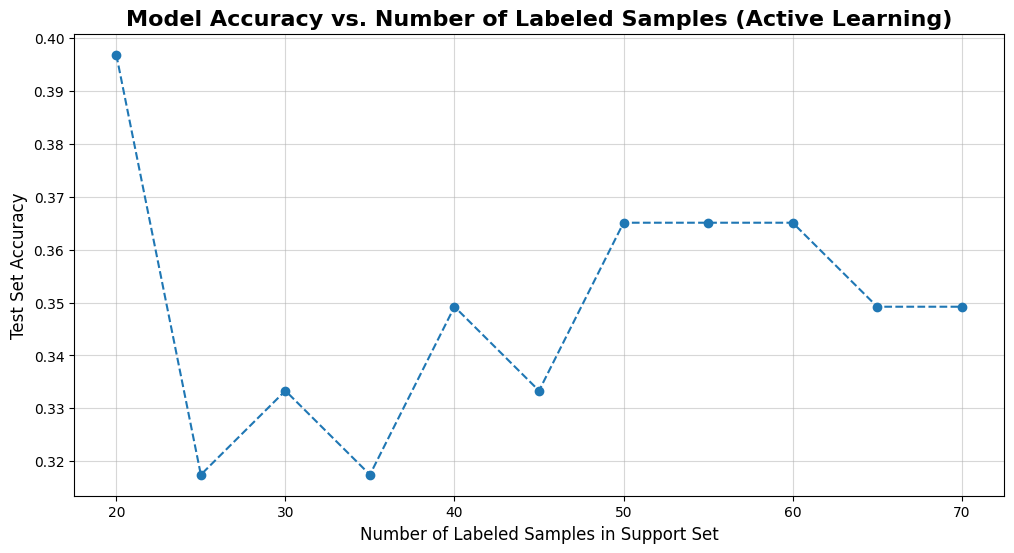


FINAL MODEL EVALUATION
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 530ms/step

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  exc_solder       0.17      0.19      0.18        16
        good       0.64      0.42      0.51        33
 poor_solder       0.20      0.17      0.18         6
       spike       0.22      0.50      0.31         8

    accuracy                           0.35        63
   macro avg       0.31      0.32      0.29        63
weighted avg       0.42      0.35      0.37        63



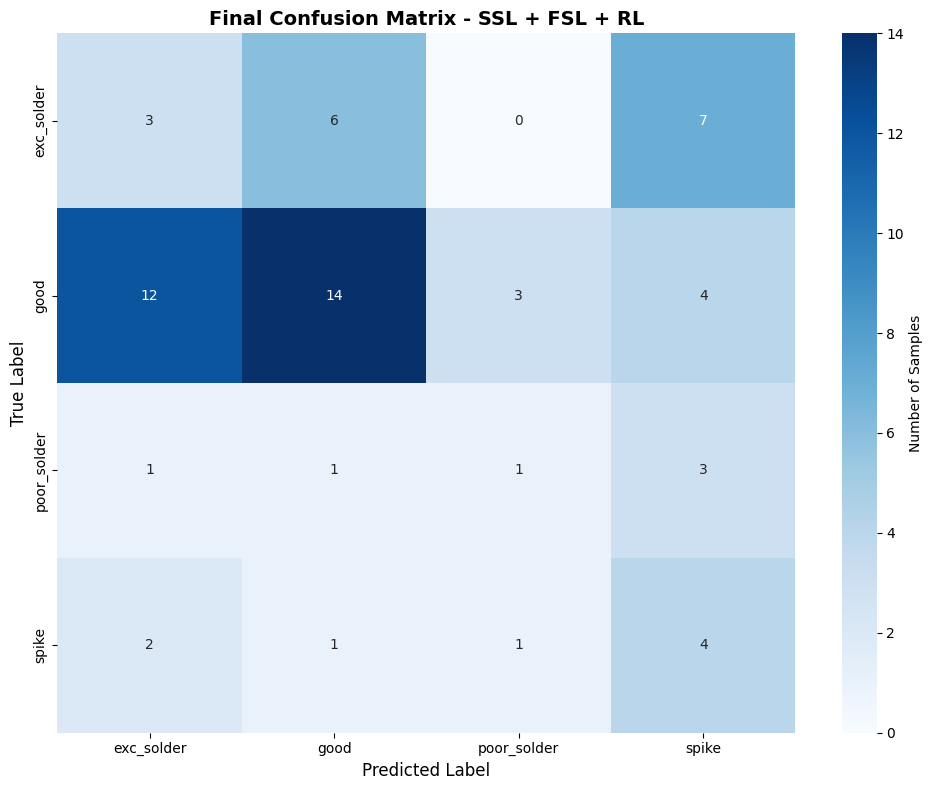

In [ ]:
# --- Plot Active Learning Performance ---
plt.figure(figsize=(12, 6))
plt.plot(history_df['support_set_size'], history_df['accuracy'], marker='o', linestyle='--')
plt.title('Model Accuracy vs. Number of Labeled Samples (Active Learning)', fontsize=16, fontweight='bold')
plt.xlabel('Number of Labeled Samples in Support Set', fontsize=12)
plt.ylabel('Test Set Accuracy', fontsize=12)
plt.grid(True, alpha=0.5)
plt.show()

# --- Final Model Evaluation ---
print("\n" + "="*70)
print("FINAL MODEL EVALUATION")
print("="*70)

final_prototypes = current_prototypes
final_predictions = classify_with_prototypes(test_df['filename'].values, fsl_encoder, final_prototypes)
final_true_classes = test_df['label_encoded'].values
class_labels = list(label_encoder.classes_)

# Generate and display classification report
print("\nCLASSIFICATION REPORT")
print("="*70)
report = classification_report(final_true_classes, final_predictions, target_names=class_labels)
print(report)

# Create and display confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(final_true_classes, final_predictions)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=class_labels, yticklabels=class_labels,
            cbar_kws={'label': 'Number of Samples'})
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Final Confusion Matrix - SSL + FSL + RL", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print per-class accuracy
print("\nPer-class accuracy:")
for i, label in enumerate(class_labels):
    if cm[i].sum() > 0:
        class_acc = cm[i, i] / cm[i].sum()
        print(f"  {label}: {class_acc:.3f} ({class_acc*100:.1f}%)")

# Error analysis visualization
print(f"\nCreating error analysis visualization...")

def create_dummy_image(size=(128, 128)):
    """Create a dummy placeholder image for visualization"""
    return np.ones((size[0], size[1], 3), dtype=np.uint8) * 255

def load_image_safe(image_path, target_size=(128, 128)):
    """Safely load an image with error handling and resizing"""
    try:
        if os.path.exists(image_path):
            image = cv2.imread(image_path)
            if image is not None:
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                image = cv2.resize(image, target_size)
                return image
    except Exception as e:
        print(f"Error loading image {image_path}: {e}")
    
    return create_dummy_image(target_size)

fig, axes = plt.subplots(len(class_labels), len(class_labels), figsize=(15, 15))
fig.suptitle('Error Analysis: Sample Images by True vs Predicted Labels (SSL+FSL+RL)', fontsize=16, fontweight='bold')

for true_idx, true_label in enumerate(class_labels):
    for pred_idx, pred_label in enumerate(class_labels):
        # Find samples for this true/predicted combination
        indices = np.where((final_true_classes == true_idx) & (final_predictions == pred_idx))[0]
        
        if len(indices) > 0:
            # Use the first sample found
            sample_idx = indices[0]
            image_path = test_df['filename'].iloc[sample_idx]
            
            # Load and display image
            sample_image = load_image_safe(image_path, TARGET_SIZE)
        else:
            # No sample exists for this combination
            sample_image = create_dummy_image(TARGET_SIZE)
        
        # Plot the image
        ax = axes[true_idx, pred_idx]
        ax.imshow(sample_image)
        ax.set_title(f"T: {true_label}\nP: {pred_label}", fontsize=8)
        if len(indices) == 0:
            ax.text(0.5, 0.5, "No Sample", transform=ax.transAxes, 
                   ha='center', va='center', fontsize=10, color='red')
        ax.axis('off')

plt.tight_layout()
plt.show()

print(f"\nEVALUATION COMPLETED")
print("Classification report generated")
print("Confusion matrix created") 
print("Error analysis performed")

In [ ]:
## 6. Save Model for Edge Deployment
import pickle

# --- Save Final Model Artifacts for Edge Deployment ---
print("\n" + "="*70)
print("SAVING FINAL MODEL FOR EDGE DEPLOYMENT")
print("="*70)

# Edge deployment optimization
print("Applying edge deployment optimizations...")

# 1. Model size analysis
encoder_size = fsl_encoder.count_params()
print(f"SSL Encoder parameters: {encoder_size:,}")
print(f"Estimated model size: ~{encoder_size * 4 / (1024*1024):.1f} MB (FP32)")
print(f"Estimated model size: ~{encoder_size / (1024*1024):.1f} MB (INT8 quantized)")

# 2. Inference speed estimation
print(f"Target image size: {TARGET_SIZE}")
print(f"Optimized for: Mobile/Edge devices")

# 3. Combine prototypes and metadata
model_artifacts = {
    'prototypes': final_prototypes,
    'class_names': list(label_encoder.classes_),
    'target_size': TARGET_SIZE,
    'model_type': 'MobileNetV2-SSL-FSL',
    'edge_optimized': True,
    'quantization_ready': True
}

# Define path for the artifacts
artifacts_path = "../model/fsl_model_artifacts.pkl"

# Save the combined artifacts
with open(artifacts_path, 'wb') as f:
    pickle.dump(model_artifacts, f)

print(f"Final model artifacts saved to: {artifacts_path}")

# 4. Save edge-optimized encoder
edge_encoder_path = "../model/ssl_encoder.weights.h5"
fsl_encoder.save_weights(edge_encoder_path)
print(f"Edge-optimized SSL encoder weights saved to: {edge_encoder_path}")

print("\nModel artifacts are ready for edge deployment.")



SAVING FINAL MODEL FOR DEPLOYMENT
Final model artifacts (prototypes, class names) saved to: ../model/fsl_model_artifacts.pkl

Model artifacts are ready for deployment.
